In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import QuantLib as ql
import rateslib as rl
import datetime
import pytz
NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC") 

In [2]:
import datetime

from BT.data_handler import TimeGrid
from BT.misc import ql_cal_date_range
from BT.query_actions import AddQueryAction, UnwindPositionsAction
from BT.query_engine import QueryDrivenBacktest
from BT.query_strategy import QueryStrategy
from BT.triggers import DateTrigger, DateTriggerRequirements

from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP

from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapStructure import IRSwapStructure
from Query.IRSwaps.IRSwapValue import IRSwapValue

In [3]:
mdp = IRSwapsMDP(source="CME_NY_EOD_LIVE-ql_basic")

# Simple MtM of Spot 2s10s

In [4]:
trade_date = datetime.date(2025, 9, 2)

query = IRSwapQuery(
    structure=IRSwapStructure.CURVE,
    value=IRSwapValue.NPV,
    curve="USD-SOFR-1D",
    structure_kwargs={"front_tenor": "2Y", "back_tenor": "10Y", "bpv": +100_000},
)

entry = DateTrigger(DateTriggerRequirements(dates=[datetime.date(2025, 9, 2)]), actions=[AddQueryAction(query=query)])
exit_ = DateTrigger(DateTriggerRequirements(dates=[datetime.date(2025, 9, 15)]), actions=[UnwindPositionsAction(match_all=True, fee=0.0)])

tg = TimeGrid(
    ql_cal_date_range(
        ql_cal=ql.UnitedStates(ql.UnitedStates.GovernmentBond),
        start=trade_date,
        end=datetime.date(2025, 9, 29),
    )
)
strategy = QueryStrategy(name="USD-SOFR-1D 2s10s", triggers=[entry, exit_])
bt = QueryDrivenBacktest(time_grid=tg, mdp=mdp, strategy=strategy)
bt.run()

BACKTESTING...: 100%|██████████| 20/20 [00:00<00:00, 22.92step/s]


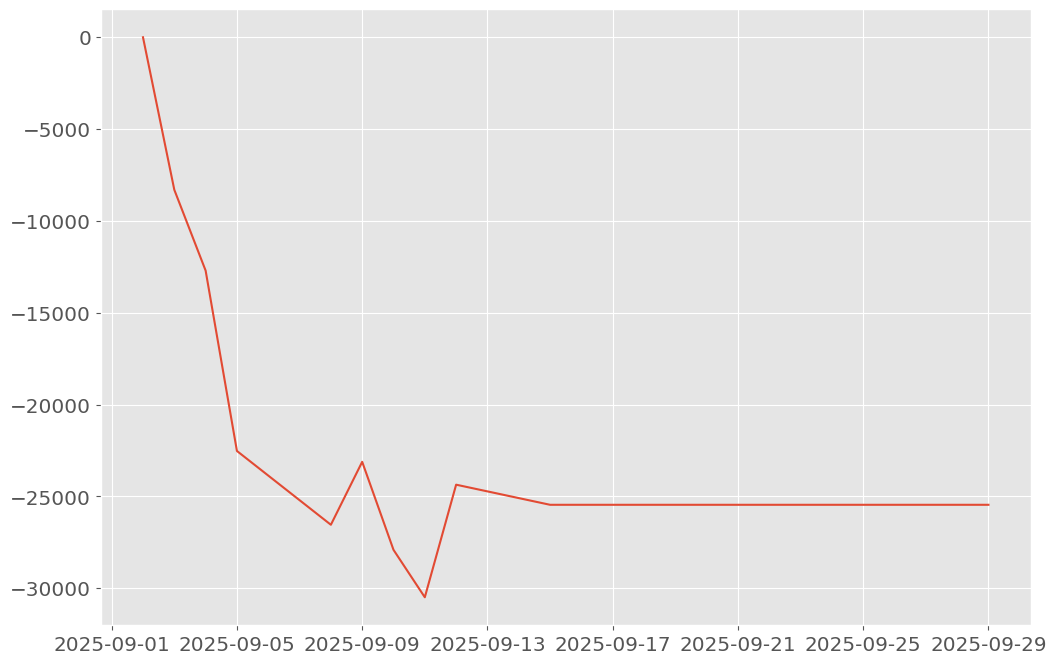

In [5]:
mtm = pd.Series(bt.mtm_history).sort_index()
plt.plot(mtm)

In [6]:
mtm

2025-09-02   -6.705523e-08
2025-09-03   -8.305703e+03
2025-09-04   -1.270572e+04
2025-09-05   -2.252861e+04
2025-09-08   -2.654765e+04
2025-09-09   -2.312004e+04
2025-09-10   -2.791277e+04
2025-09-11   -3.049610e+04
2025-09-12   -2.436458e+04
2025-09-15   -2.545954e+04
2025-09-16   -2.545954e+04
2025-09-17   -2.545954e+04
2025-09-18   -2.545954e+04
2025-09-19   -2.545954e+04
2025-09-22   -2.545954e+04
2025-09-23   -2.545954e+04
2025-09-24   -2.545954e+04
2025-09-25   -2.545954e+04
2025-09-26   -2.545954e+04
2025-09-29   -2.545954e+04
dtype: float64